# **Data Analyst Professional Practical Exam Submission (Bohdan Khomenko)**

**This report presents an in-depth analysis of sales data to assess sales performance, customer behavior, and revenue trends. The goal is to clean and validate the dataset, conduct exploratory data analysis, define a key business metric, and provide actionable recommendations.**

**The dataset consists of 15,000 records covering different sales methods, customer interactions, and revenue figures. By analyzing this data, we aim to identify key insights that can help improve sales strategies and optimize revenue generation.**

In [137]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Validation and Cleaning

### Data Overview

The dataset consists of 15,000 entries with the following columns:

`week` (int): Represents the week of the year.

`sales_method` (str): Method used to make the sale.

`customer_id` (str): Unique identifier for customers.

`nb_sold` (int): Number of items sold.

`revenue` (float): Revenue generated.

`years_as_customer` (int): Number of years the customer has been with the company.

`nb_site_visits` (int): Number of times the customer visited the website.

`state` (str): The state in which the customer resides.

In [138]:
sales = pd.read_csv("product_sales.csv")
sales.head()

,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state
0,2,Email,2e72d641-95ac-497b-bbf8-4861764a7097,10,NaN,0,24,Arizona
1,6,Email + Call,3998a98d-70f5-44f7-942e-789bb8ad2fe7,15,225.47,1,28,Kansas
2,5,Call,d1de9884-8059-4065-b10f-86eef57e4a44,11,52.55,6,26,Wisconsin
3,4,Email,78aa75a4-ffeb-4817-b1d0-2f030783c5d7,11,NaN,3,25,Indiana
4,3,Email,10e6d446-10a5-42e5-8210-1b5438f70922,9,90.49,0,28,Illinois


In [139]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   week               15000 non-null  int64  
 1   sales_method       15000 non-null  object 
 2   customer_id        15000 non-null  object 
 3   nb_sold            15000 non-null  int64  
 4   revenue            13926 non-null  float64
 5   years_as_customer  15000 non-null  int64  
 6   nb_site_visits     15000 non-null  int64  
 7   state              15000 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 937.6+ KB


In [140]:
sales.describe()

,week,nb_sold,revenue,years_as_customer,nb_site_visits
count,15000.000000,15000.000000,13926.000000,15000.000000,15000.000000
mean,3.098267,10.084667,93.934943,4.965933,24.990867
std,1.656420,1.812213,47.435312,5.044952,3.500914
min,1.000000,7.000000,32.540000,0.000000,12.000000
25%,2.000000,9.000000,52.470000,1.000000,23.000000
50%,3.000000,10.000000,89.500000,3.000000,25.000000
75%,5.000000,11.000000,107.327500,7.000000,27.000000
max,6.000000,16.000000,238.320000,63.000000,41.000000


In [141]:
sales.dtypes

week                   int64
sales_method          object
customer_id           object
nb_sold                int64
revenue              float64
years_as_customer      int64
nb_site_visits         int64
state                 object
dtype: object

## Cleaning Steps:

1. 	Standardizing `sales_method` Values
2. 	Handling Missing `revenue` Values
3.	Ensuring `state` Consistency

In [142]:
print(sales['sales_method'].value_counts())

Email           7456
Call            4962
Email + Call    2549
em + call         23
email             10
Name: sales_method, dtype: int64


In [143]:
sales['sales_method'] = sales['sales_method'].astype(str).str.lower().str.strip()

sales_method_mapping = {
    'email': 'Email',
    'call': 'Call',
    'email + call': 'Email + Call',
    'em + call': 'Email + Call'
}

sales['sales_method'] = sales['sales_method'].map(sales_method_mapping)
sales['sales_method'].fillna('Unknown', inplace=True)

print(f"Number of unique Sales Methods: {sales['sales_method'].nunique()}")
print(f"Unique Sales Methods: {sales['sales_method'].unique()}")

# Handling missing revenue
mean_revenue_by_sales_method = sales.groupby('sales_method')['revenue'].mean()
sales['revenue'] = sales['revenue'].fillna(sales['sales_method']
                                           .map(mean_revenue_by_sales_method)).fillna(sales['revenue'].mean())

Number of unique Sales Methods: 3
Unique Sales Methods: ['Email' 'Email + Call' 'Call']


In [144]:
sales['state'] = sales['state'].str.strip()
print(sales['state'].unique())

['Arizona' 'Kansas' 'Wisconsin' 'Indiana' 'Illinois' 'Mississippi'
 'Georgia' 'Oklahoma' 'Massachusetts' 'Missouri' 'Texas' 'New York'
 'Maryland' 'California' 'Tennessee' 'Pennsylvania' 'North Dakota'
 'Florida' 'Michigan' 'North Carolina' 'Hawaii' 'Colorado' 'Louisiana'
 'Virginia' 'New Mexico' 'Arkansas' 'Alaska' 'Oregon' 'New Hampshire'
 'Ohio' 'New Jersey' 'Connecticut' 'Iowa' 'Montana' 'Washington'
 'Kentucky' 'Alabama' 'Nebraska' 'South Carolina' 'Minnesota'
 'South Dakota' 'Delaware' 'Maine' 'Utah' 'West Virginia' 'Vermont'
 'Rhode Island' 'Nevada' 'Idaho' 'Wyoming']


In [145]:
duplicates = sales[sales.duplicated()]
print(f"Number of duplicate rows: {duplicates.shape[0]}")

Number of duplicate rows: 0


In [146]:
print(sales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   week               15000 non-null  int64  
 1   sales_method       15000 non-null  object 
 2   customer_id        15000 non-null  object 
 3   nb_sold            15000 non-null  int64  
 4   revenue            15000 non-null  float64
 5   years_as_customer  15000 non-null  int64  
 6   nb_site_visits     15000 non-null  int64  
 7   state              15000 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 937.6+ KB
None


# Exploratory Analysis

## Single Variable Analysis

### Distribution of `sales_method`

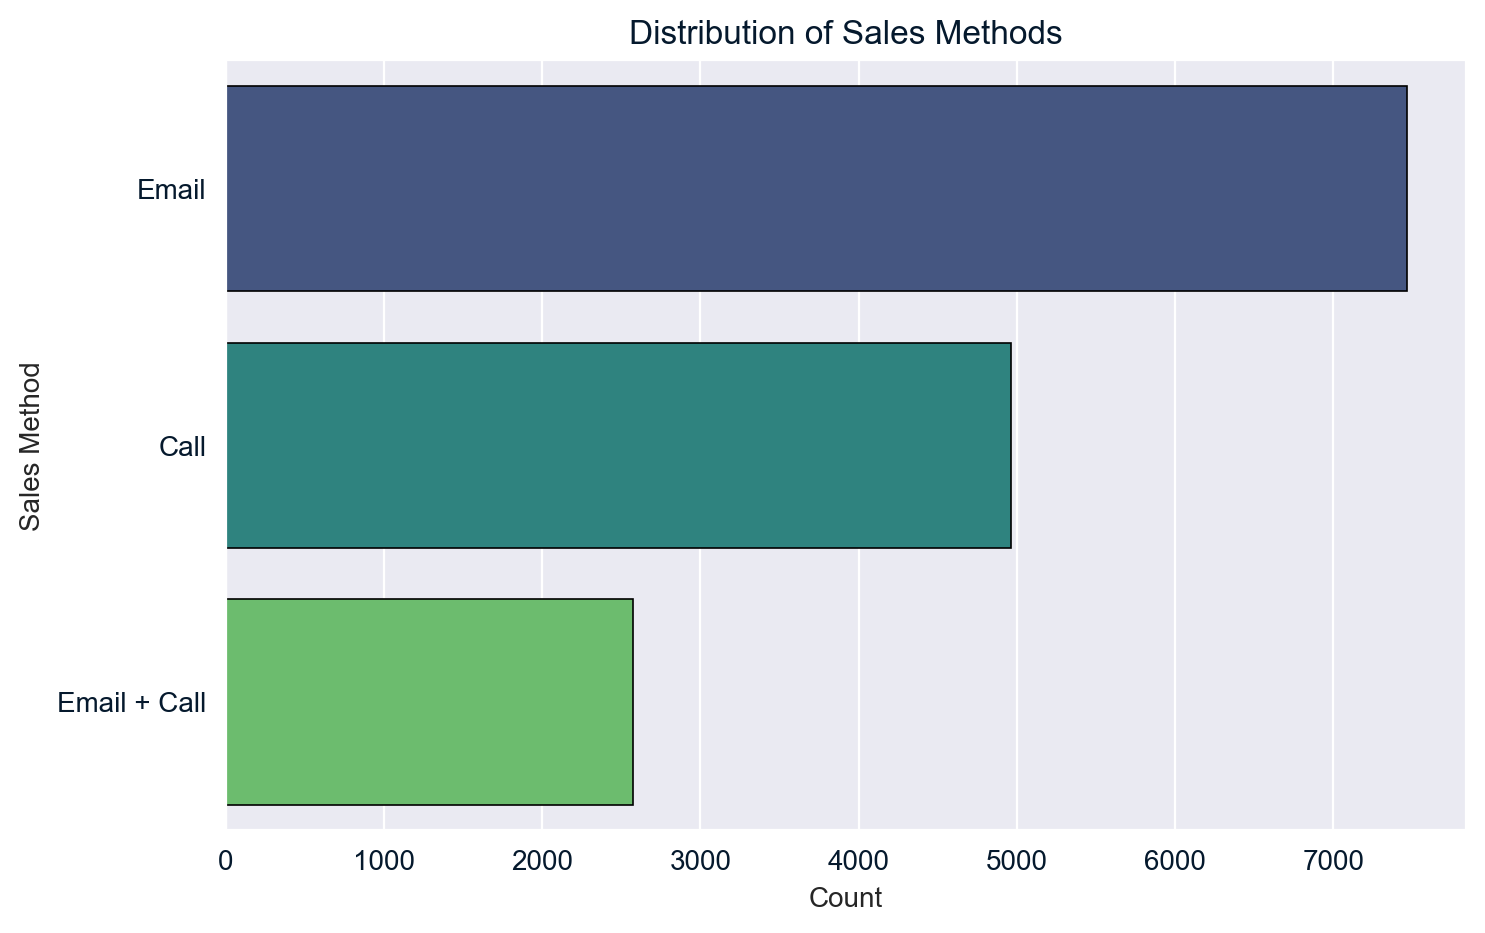

In [147]:
sns.set_style("darkgrid")
plt.figure(figsize=(8, 5))
sns.countplot(y=sales['sales_method'], order=sales['sales_method'].value_counts().index, palette="viridis", edgecolor='black', linewidth=0.6)
plt.title("Distribution of Sales Methods")
plt.xlabel("Count")
plt.ylabel("Sales Method")
plt.show()

### **Findings**: The majority of sales were conducted via email, followed by call and the combination of email + call

### Distribution of `revenue`

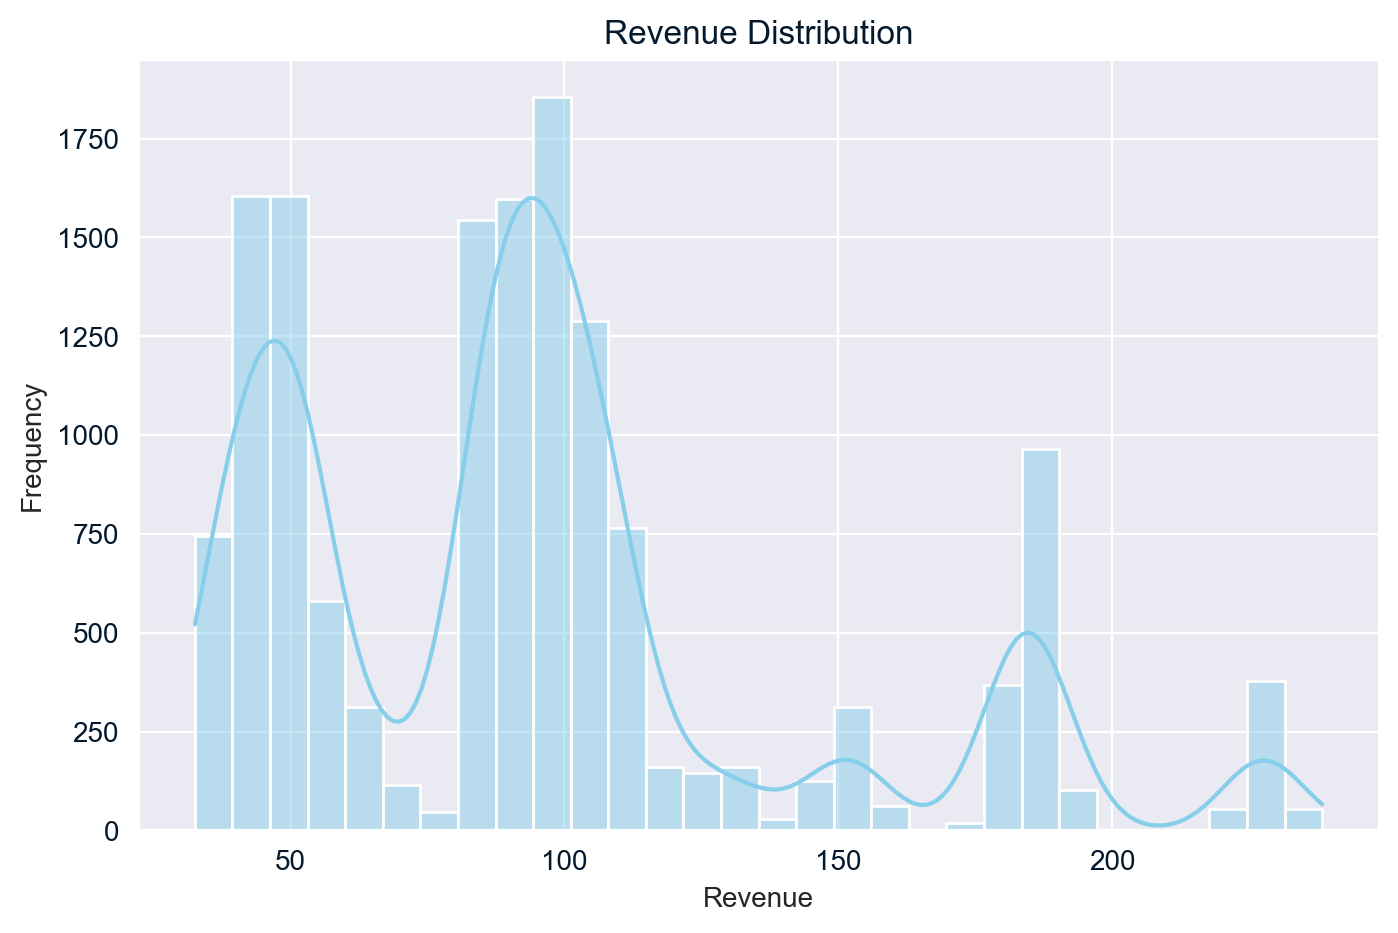

In [148]:
plt.figure(figsize=(8, 5))
sns.histplot(sales['revenue'], bins=30, kde=True, color="skyblue")
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

### **Findings**: Revenue distribution is right-skewed, indicating a few high-value transactions

## Multi-Variable Analysis

### Relationship Between `nb_sold` and `revenue`

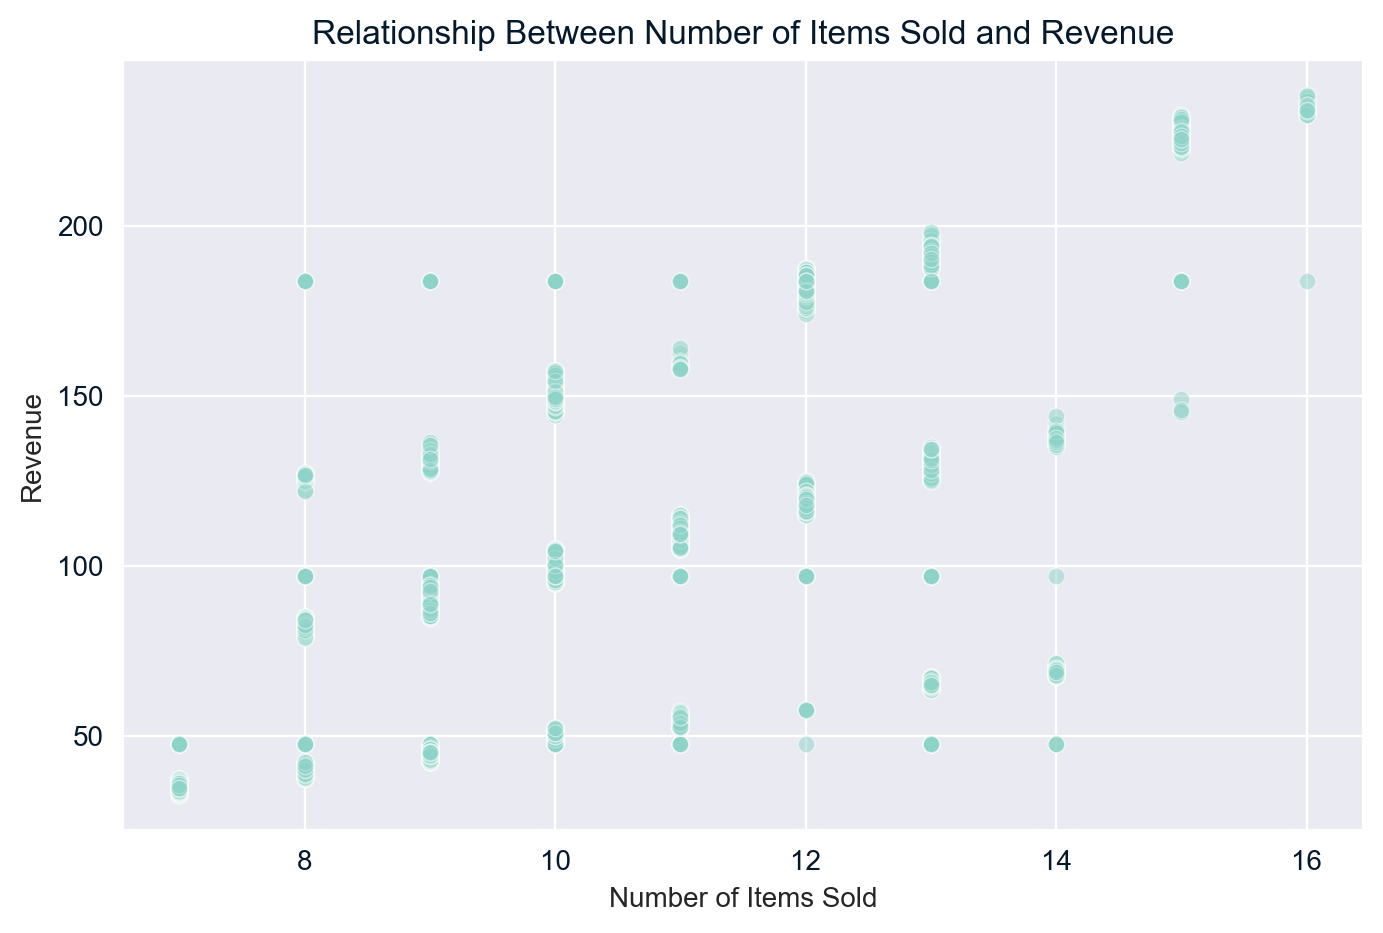

In [149]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=sales['nb_sold'], y=sales['revenue'], alpha=0.5)
plt.title("Relationship Between Number of Items Sold and Revenue")
plt.xlabel("Number of Items Sold")
plt.ylabel("Revenue")
plt.show()

### **Findings**: There is a strong positive correlation between the number of items sold and revenue, indicating that increasing sales volume leads to higher revenue

# Business Metric Definition

## Key Metric: _Average Revenue per Sale_ (`ARPS`) 
Business Importance:

- Performance Indicator: This metric measures the efficiency of sales efforts by showing how much revenue is generated per unit sold.

- Revenue Forecasting: Helps predict future revenue based on projected sales volume.

- Strategy Optimization: Allows businesses to compare the effectiveness of different sales methods (email, call, or both) in maximizing revenue.

- Customer Value Assessment: Identifies high-value sales strategies by analyzing trends in revenue per sale across different customer segments.

### **Formula and Estimated Initial Value:**

In [150]:
average_revenue_per_sale = sales['revenue'].sum() / sales['nb_sold'].sum()
print(f'Average Revenue Per Sale: ' + str(round(average_revenue_per_sale,3)))   

Average Revenue Per Sale: 9.478


### How the Business Should Use This Metric:

🔹 Monitor Trends Over Time: Track changes in Average Revenue per Sale to assess the impact of marketing campaigns and sales strategies.

🔹 Compare Across Sales Channels: Evaluate whether email, call, or a combination yields the highest revenue per unit sold.

🔹 Optimize Pricing Strategies: If the metric declines, investigate whether discounting or changes in customer behavior are driving lower revenues per sale.

🔹 Identify High-Value Customers: Segment customers based on their average revenue contribution to focus on retention and targeted marketing.

## Supplemental Metric: Revenue Per Customer (`RPC`)
While ARPS focuses on individual sales, Revenue Per Customer (RPC) provides additional insight by measuring how much revenue is generated per unique customer.

**Why `RPC`?**
- Customer Value Assessment: Helps determine which customer segments contribute the most revenue.
- Retention & Loyalty Insights: A declining RPC may indicate a need for better customer engagement strategies.
- Marketing Effectiveness: High RPC suggests strong customer purchasing power and better monetization of each acquired customer.


### **Formula and Estimated Value:**

In [151]:
rpc = sales['revenue'].sum() / sales['customer_id'].nunique()
print(f'Revenue Per Customer: {round(rpc, 2)}')

Revenue Per Customer: 95.58


### How the Business Should Use This Metric:
🔹 **Identify High-Value Customers**: Focus marketing efforts on customers who generate the highest revenue.

🔹 **Compare Across Sales Methods**: Determine if certain methods attract higher-spending customers.

🔹 **Monitor Customer Spending Trends**: If RPC declines, investigate whether customers are purchasing less frequently or spending less per transaction.

# Final Summary & Recommendations

## Summary:

1. The dataset was cleaned to ensure consistency.

2. **Email** is the most common sales method.

3. **Revenue** is skewed, with a few high-value sales contributing significantly.

4. There is a **strong positive correlation** between the number of items sold and revenue.

5. **Average Revenue per Sale** is a key business metric that provides insight into revenue efficiency.

## Recommendations:

- **Optimize Email Campaigns**: Given its high frequency, improving email sales strategies can boost revenue.

- **Monitor Average Revenue per Sale Closely**: Regularly track this metric to evaluate performance and detect changes in sales efficiency.

- **Enhance Multi-Channel Strategies**: Encouraging the use of both email and call together may improve sales outcomes.

- **Refine Pricing & Discount Strategies**: Analyze whether discounting is affecting revenue per sale and adjust accordingly.

- **Segment and Target High-Value Customers**: Focus on customers who generate the highest revenue per sale to drive growth.